<a href="https://colab.research.google.com/github/c0b23144/oxford_pet_diffusion_generate/blob/main/oxford_pet_generate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install -q torch torchvision

In [9]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

transform = transforms.Compose([
    transforms.Resize(
        (128, 128),
        interpolation=InterpolationMode.BICUBIC
        ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

print("画像枚数:", len(dataset))

画像枚数: 3680


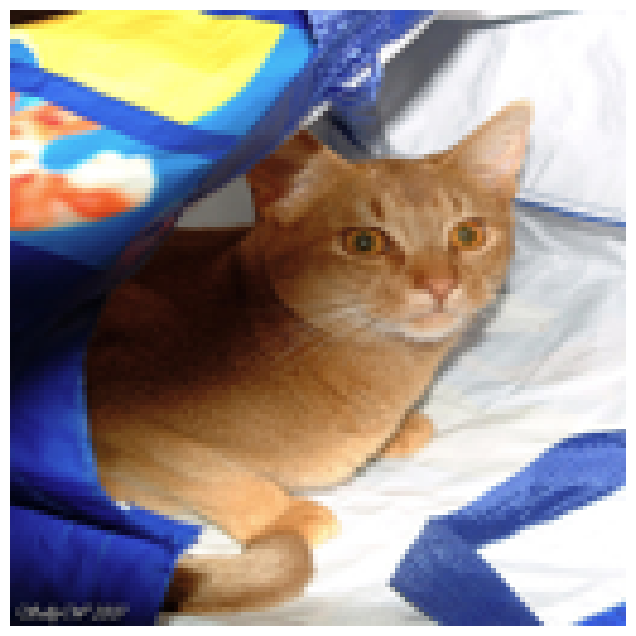

ラベル: 0


In [10]:
import matplotlib.pyplot as plt

image, label = dataset[0]

# -1～1 ⇒ 0～1に戻す
image = image * 0.5 + 0.5

plt.figure(figsize=(8, 8))
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

print("ラベル:", label)

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# diffusionのステップ数
T = 1000

# ノイズの強さ
beta = torch.linspace(
    0.0001,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def add_noise(x, t):
    # ランダムなノイズ
    noise = torch.randn_like(x)
